This notebook contains the code to generate the plot in Figure 1c in the paper.

Before running this notebook, download the models from [this google drive folder](https://drive.google.com/drive/folders/1hjIIgxO5LfufE07D9bzazIOwqyfRRy6d?usp=sharing) and save them to a folder named "trained_models".

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from model.modeling_GPT2Noisy_nano import NoisyGPT, NoisyGPTConfig

device = 'mps'

In [ ]:
model0p0 = "trained_models/ckpt_16000_lambda0.0.pt"
model0p001 = "trained_models/ckpt_16000_lambda0.001.pt"
model0p01 = "trained_models/ckpt_16000_lambda0.01.pt"
model0p1 = "trained_models/ckpt_16000_lambda0.1.pt"
model1p0 = "trained_models/ckpt_16000_lambda1.0.pt"

In [3]:
def load_model(ckpt_path, device=device):
    """Rebuild model from ckpt['model_args'] and load weights; tolerate _orig_mod prefix."""
    ckpt = torch.load(ckpt_path, map_location="cpu")
    cfg = NoisyGPTConfig(**ckpt.get("model_args", {}))
    model = NoisyGPT(cfg)

    state_dict = ckpt["model"]
    # Clean potential compile prefix
    if any(k.startswith("_orig_mod.") for k in state_dict.keys()):
        new_sd = {}
        for k, v in state_dict.items():
            new_sd[k[len("_orig_mod."):] if k.startswith("_orig_mod.") else k] = v
        state_dict = new_sd

    model.load_state_dict(state_dict, strict=False)
    model.to(device).eval()
    return model

In [ ]:
def extract_theta_matrix(model, softplus=True):
   
    vals = []
    for block in model.transformer.h:
        t = block.attn._theta.detach().to("cpu")
        if softplus:
            t = torch.nn.functional.softplus(t)
        vals.append(t.numpy())
    return np.stack(vals, axis=0)

In [ ]:
# Load both models
m_0p0 = load_model(model0p0, device)  # lambda 0.0
m_0p001 = load_model(model0p001, device)  # lambda 0.001
m_0p01 = load_model(model0p01, device)  # lambda 0.01
m_0p1 = load_model(model0p1, device)  # lambda 0.1
m_1p0 = load_model(model1p0, device)  # lambda 1.0

# Extract per-layer x per-head theta (softplus)
theta_0p0 = extract_theta_matrix(m_0p0, softplus=True)
theta_0p001 = extract_theta_matrix(m_0p001, softplus=True)
theta_0p01 = extract_theta_matrix(m_0p01, softplus=True)
theta_0p1 = extract_theta_matrix(m_0p1, softplus=True)
theta_1p0 = extract_theta_matrix(m_1p0, softplus=True)

number of parameters: 123.59M
number of parameters: 123.59M
number of parameters: 123.59M
number of parameters: 123.59M
number of parameters: 123.59M


In [8]:
theta_0p0

array([[0.02954292, 0.03058652, 0.03113372, 0.03104598, 0.03143902,
        0.03145806, 0.03010046, 0.03314804, 0.03061517, 0.03036473,
        0.03071462, 0.03118915],
       [0.05273489, 0.08645725, 0.03312117, 0.09776103, 0.04687345,
        0.05611269, 0.17003086, 0.0663266 , 0.10660612, 0.10799859,
        0.09096675, 0.05895872],
       [0.03803473, 0.12738648, 0.12339273, 0.07441118, 0.16852   ,
        0.06666227, 0.10694076, 0.13722156, 0.18678322, 0.09477343,
        0.07434858, 0.1506061 ],
       [0.11569776, 0.07189506, 0.08659501, 0.13416937, 0.16529267,
        0.2595241 , 0.14121047, 0.04272047, 0.14880617, 0.10526031,
        0.10042284, 0.05224483],
       [0.09074686, 0.20595284, 0.12244955, 0.05779185, 0.03179599,
        0.12966292, 0.04206553, 0.08989802, 0.14827414, 0.09194906,
        0.09467907, 0.104808  ],
       [0.46770054, 0.25722796, 0.1790664 , 0.25463825, 0.12392421,
        0.2812528 , 0.09048969, 0.34888408, 0.5142044 , 0.0549646 ,
        0.124006  ,

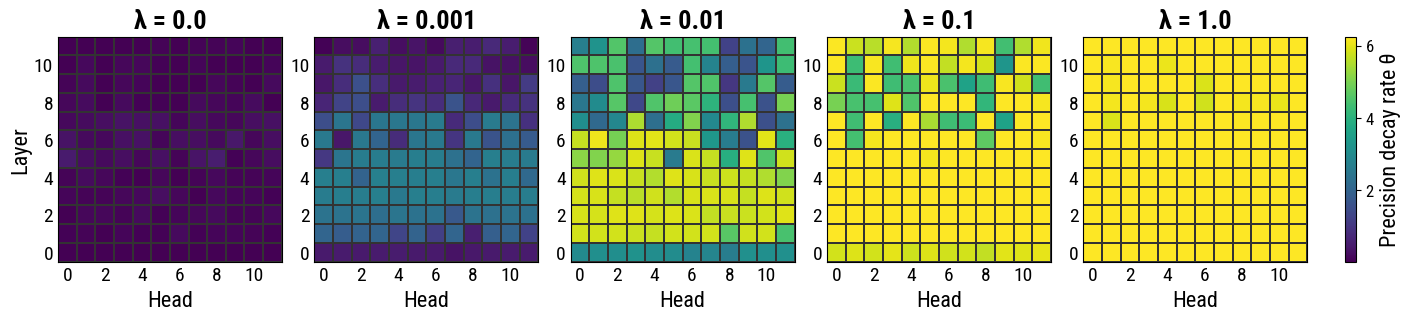

In [ ]:
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 19,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "font.family": "Roboto Condensed"
})

# Shared color scale
vmin = min(theta_0p0.min(), theta_0p001.min(), theta_0p01.min(), theta_0p1.min(), theta_1p0.min())
vmax = max(theta_0p0.max(), theta_0p001.max(), theta_0p01.max(), theta_0p1.max(), theta_1p0.max())

fig, axes = plt.subplots(1, 5, figsize=(14, 3.1), constrained_layout=True)

arrays = [theta_0p0, theta_0p001, theta_0p01, theta_0p1, theta_1p0]
titles = ["λ = 0.0", "λ = 0.001", "λ = 0.01", "λ = 0.1", "λ = 1.0"]

for i, (ax, arr, title) in enumerate(zip(axes, arrays, titles)):

    im = ax.pcolormesh(arr, cmap='viridis', vmin=vmin, vmax=vmax,
                       edgecolors='0.2', linewidths=0.05)
    
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer" if i == 0 else "")
    ax.yaxis.labelpad = 2

    n_layers, n_heads = arr.shape
    ax.set_xticks(np.arange(0.5, n_heads, 2))
    ax.set_yticks(np.arange(0.5, n_layers, 2))

    ax.set_xticklabels(np.arange(0, n_heads, 2))
    ax.set_yticklabels(np.arange(0, n_layers, 2))

    ax.set_ylim(0, n_layers)
    ax.set_xlim(0, n_heads)

    ax.tick_params(which='both', length=0)

# Single vertical colorbar
cbar = fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.046, pad=0.03)
cbar.set_label("Precision decay rate θ", fontsize=16, fontfamily="Roboto Condensed")
cbar.ax.tick_params(labelsize=12)

# plt.savefig("plots_ACL/learned_thetas.pdf", bbox_inches="tight", pad_inches=0.05)
plt.show()

/var/folders/4k/_kj6xmhj7tbbbj61g0kc59280000gn/T/ipykernel_29194/3099686441.py:53: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.1)  # reserve space for the horizontal cbar


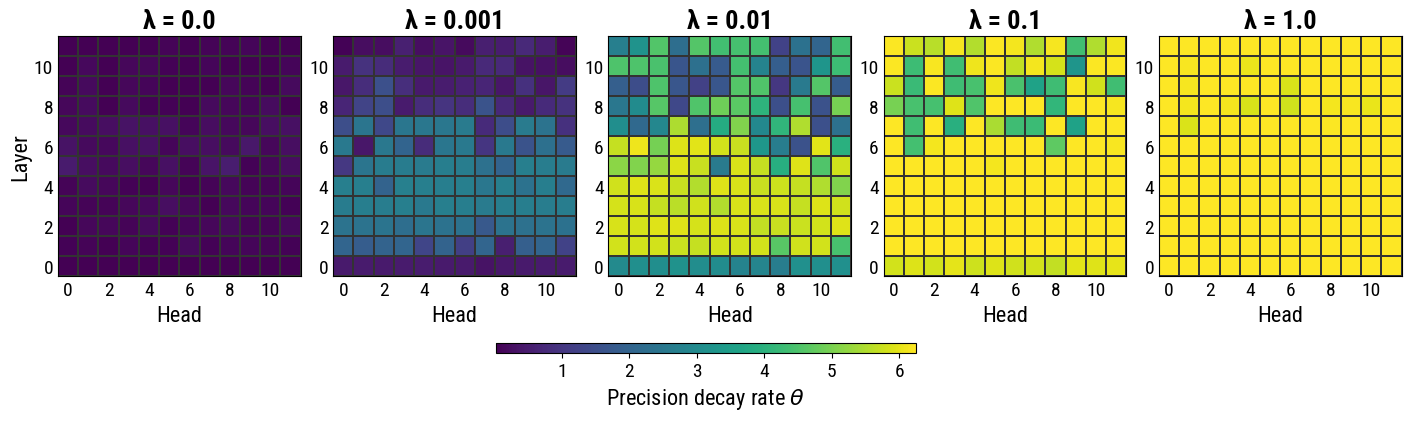

In [ ]:
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 19,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "font.family": "Roboto Condensed"
})

# Shared color scale
vmin = min(theta_0p0.min(), theta_0p001.min(), theta_0p01.min(), theta_0p1.min(), theta_1p0.min())
vmax = max(theta_0p0.max(), theta_0p001.max(), theta_0p01.max(), theta_0p1.max(), theta_1p0.max())

fig, axes = plt.subplots(1, 5, figsize=(14, 3.25), constrained_layout=True)

arrays = [theta_0p0, theta_0p001, theta_0p01, theta_0p1, theta_1p0]
titles = ["λ = 0.0", "λ = 0.001", "λ = 0.01", "λ = 0.1", "λ = 1.0"]

for i, (ax, arr, title) in enumerate(zip(axes, arrays, titles)):

    im = ax.pcolormesh(arr, cmap='viridis', vmin=vmin, vmax=vmax,
                       edgecolors='0.2', linewidths=0.05)
    
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer" if i == 0 else "")
    ax.yaxis.labelpad = 2

    n_layers, n_heads = arr.shape
    ax.set_xticks(np.arange(0.5, n_heads, 2))
    ax.set_yticks(np.arange(0.5, n_layers, 2))

    ax.set_xticklabels(np.arange(0, n_heads, 2))
    ax.set_yticklabels(np.arange(0, n_layers, 2))

    ax.set_ylim(0, n_layers)
    ax.set_xlim(0, n_heads)

    ax.tick_params(which='both', length=0)

plt.subplots_adjust(bottom=0.1)  # reserve space for the horizontal cbar

cbar_ax = fig.add_axes([0.35, -0.07, 0.3, 0.03])  # left, bottom, width, height
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(r"Precision decay rate $\theta$")

# plt.savefig("plots_HSP/learned_thetas_presentation.pdf", bbox_inches="tight", pad_inches=0.05)
plt.show()